In [1]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten
from tensorflow.keras.datasets import fashion_mnist
import matplotlib.pyplot as plt
import numpy as np

In [2]:
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
X_train = X_train/255.0
X_test = X_test/255.0

In [4]:
X_train = X_train.reshape(-1,28,28,1)
X_test = X_test.reshape(-1,28,28,1)

In [7]:
model = Sequential()
model.add(Conv2D(32, (3,3), activation='relu',input_shape=(28,28,1)))
model.add(MaxPooling2D((2,2)))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
model.add(Conv2D(64,(3,3),activation='relu'))

In [9]:
model.add(Flatten())

In [10]:
model.add(Dense(128,activation='relu'))

In [11]:
model.add(Dense(10,activation='softmax'))

In [12]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [13]:
history=model.fit(X_train,y_train,epochs=10,validation_split=0.2,verbose=1)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 67s 44ms/step - accuracy: 0.8521 - loss: 0.4160 - val_accuracy: 0.8884 - val_loss: 0.3120
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 82s 44ms/step - accuracy: 0.9043 - loss: 0.2640 - val_accuracy: 0.8881 - val_loss: 0.2977
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 67s 44ms/step - accuracy: 0.9203 - loss: 0.2160 - val_accuracy: 0.9093 - val_loss: 0.2484
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 70s 46ms/step - accuracy: 0.9335 - loss: 0.1783 - val_accuracy: 0.9197 - val_loss: 0.2208
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 80s 53ms/step - accuracy: 0.9467 - loss: 0.1420 - val_accuracy: 0.9189 - val_loss: 0.2323
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 66s 44ms/step - accuracy: 0.9581 - loss: 0.1135 - val_accuracy: 0.9136 - val_loss: 0.2631
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 78s 41ms/step - accuracy: 0.9678 - loss: 0.0896 - val_accuracy: 0.9153 - val_loss: 0.2681
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 82s 42ms/step - accuracy: 0.9732 -

In [14]:
loss, accuracy = model.evaluate(X_test, y_test)
print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

#

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9148 - loss: 0.3806
Test Loss: 0.38059180974960327
Test Accuracy: 0.9147999882698059


In [15]:
predictions = model.predict(X_test)

class_names=[
    'T-shirt/top',
    'Trouser',
    'Pullover',
    'Dress',
    'Coat',
    'Sandal',
    'Shirt',
    'Sneaker',
    'Bag',
    'Ankle boot'
]

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step


In [16]:
for i in range(10):
  predicted_label = np.argmax(predictions[i])

  print("Predicted: ", class_names[predicted_label])
  print("Actual: ", class_names[y_test[i]])

Predicted:  Ankle boot
Actual:  Ankle boot
Predicted:  Pullover
Actual:  Pullover
Predicted:  Trouser
Actual:  Trouser
Predicted:  Trouser
Actual:  Trouser
Predicted:  Shirt
Actual:  Shirt
Predicted:  Trouser
Actual:  Trouser
Predicted:  Coat
Actual:  Coat
Predicted:  Shirt
Actual:  Shirt
Predicted:  Sandal
Actual:  Sandal
Predicted:  Sneaker
Actual:  Sneaker


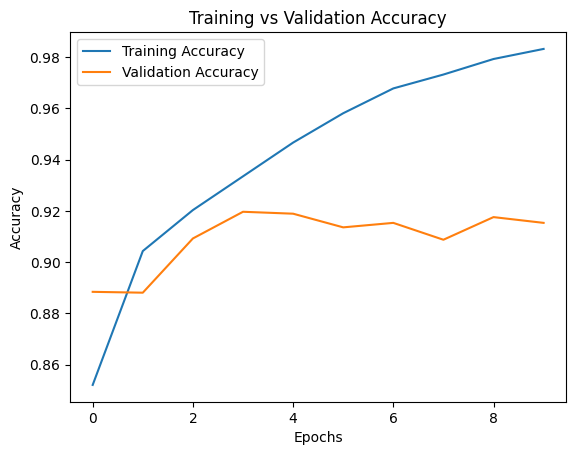

In [17]:
plt.plot(history.history['accuracy'],
         label='Training Accuracy')

plt.plot(history.history['val_accuracy'],
         label='Validation Accuracy')

plt.xlabel("Epochs")
plt.ylabel("Accuracy")

plt.title("Training vs Validation Accuracy")

plt.legend()

plt.show()